# 02. Exploratory Analysis

Where the dataset gets a face. The goal here is not decoration: each figure
either answers a research question directly or sets up a control the
regression notebooks will need. All figures are also saved to
`reports/figures/`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src import data_prep, eda, stats_analysis, modeling
from src.plotting import apply_style

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
df = eda.load_processed()
eda.FIG_DIR.mkdir(parents=True, exist_ok=True)
eda.summary_table(df)

,count,mean,std,min,25%,50%,75%,max
impressions,"3,500.0000","1,323.9034","1,409.3198",48.0000,493.0000,879.5000,"1,656.2500","17,825.0000"
clicks,"3,500.0000",57.3509,67.9627,0.0000,19.0000,37.0000,70.0000,"1,364.0000"
cost,"3,430.0000",740.4203,891.4955,0.0000,242.7600,464.7550,914.1100,"12,186.5400"
conversions,"3,430.0000",4.1837,6.8627,0.0000,1.0000,2.0000,5.0000,131.0000
ctr,"3,500.0000",0.0434,0.0158,0.0000,0.0323,0.0415,0.0521,0.1182
cvr,"3,428.0000",0.0662,0.0574,0.0000,0.0253,0.0577,0.0960,0.5000
cpc,"3,428.0000",13.1853,3.4876,2.0600,10.8660,13.3298,15.5884,24.7784
roas,"3,428.0000",15.4023,18.1697,0.0000,3.9392,10.5846,20.1756,186.7198


## How the two targets are distributed

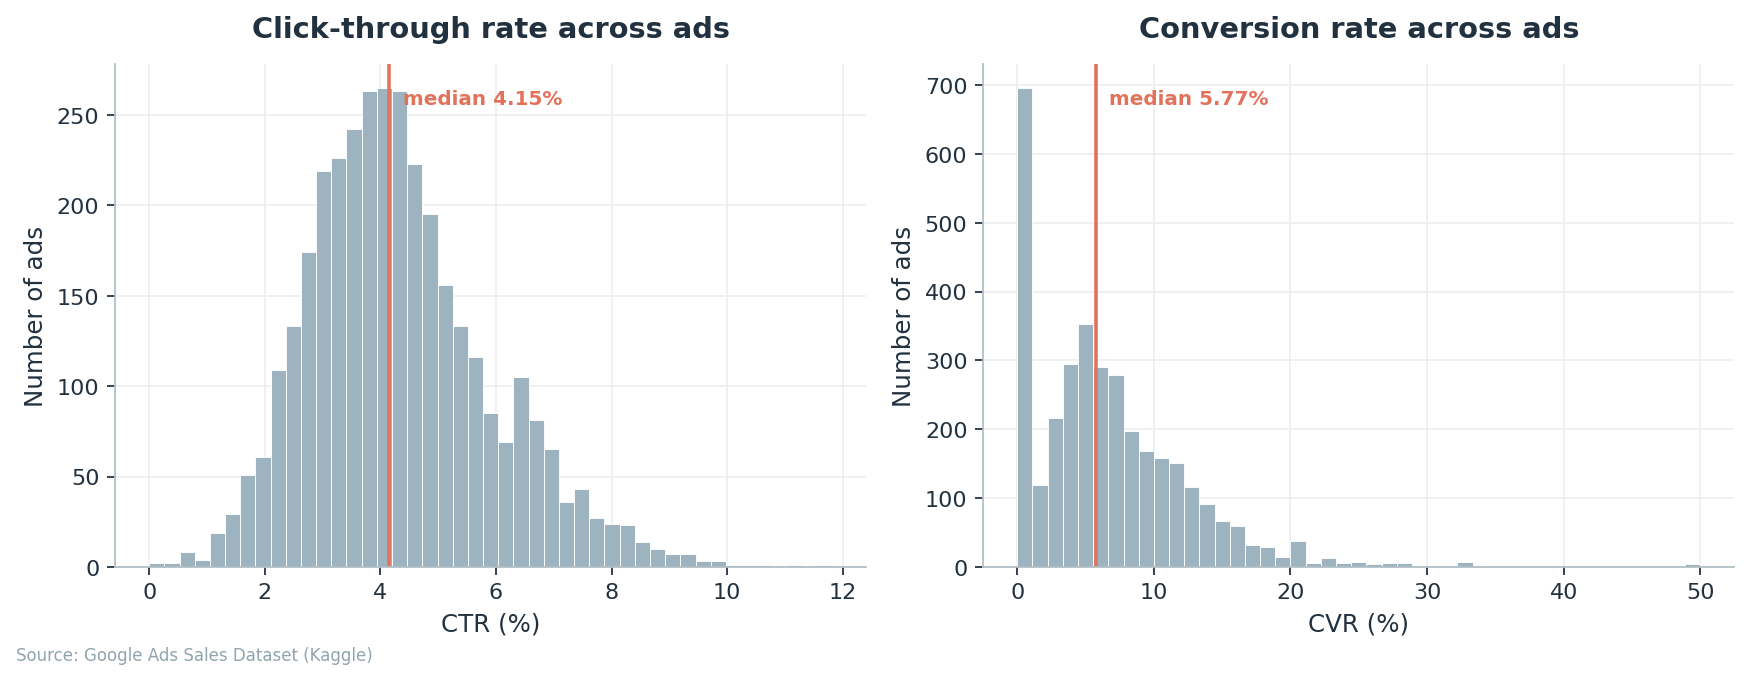

In [3]:
eda.fig_rate_distributions(df)
display(Image("reports/figures/01_rate_distributions.png"))

Both rates are right skewed, which is normal for ads data: most ads sit near
the account average and a small group performs far above it. The skew is why
the hypothesis tests later use rank based methods instead of plain t tests.

## The three splits that matter

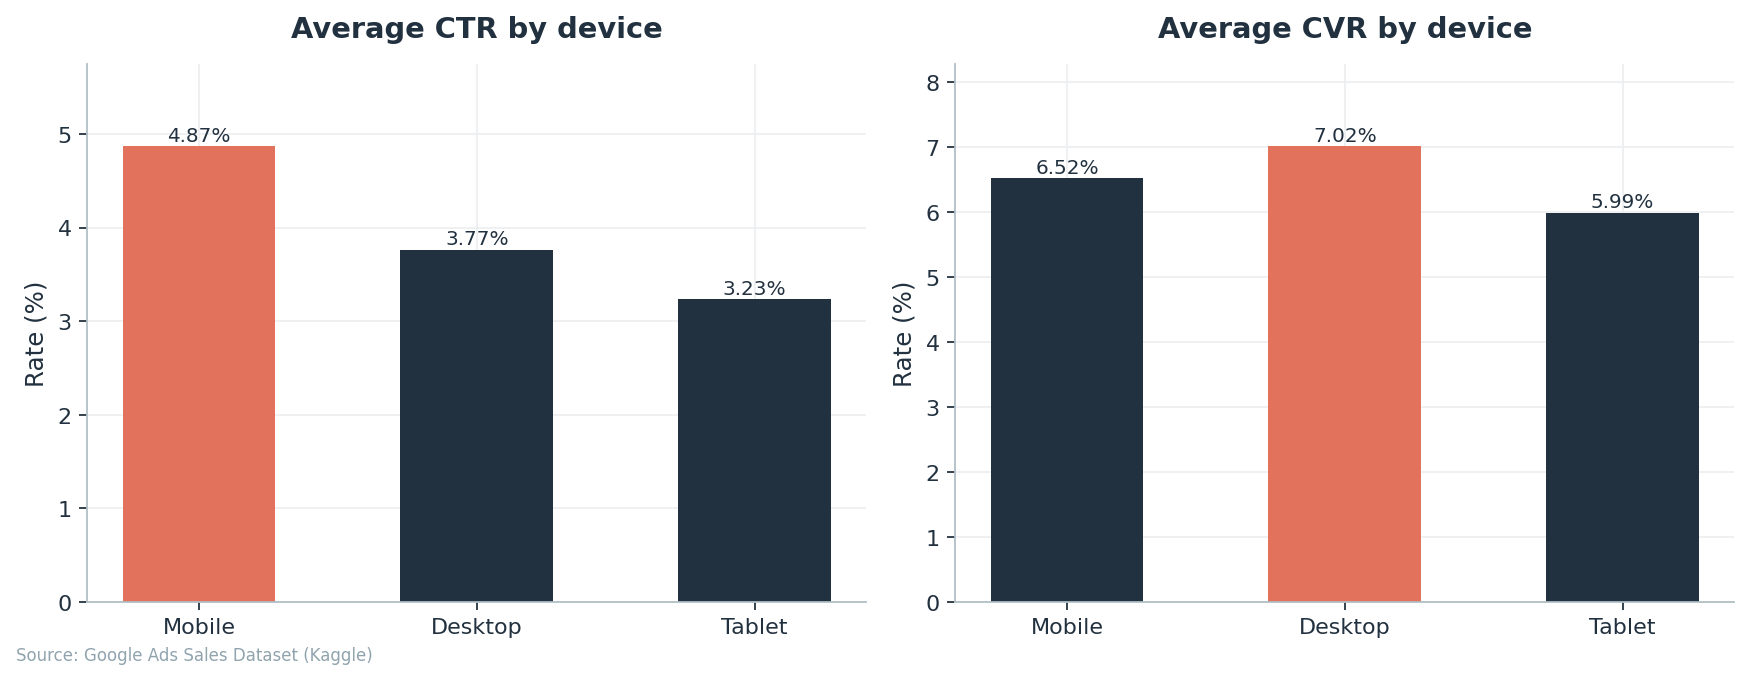

In [4]:
eda.fig_device_split(df)
display(Image("reports/figures/02_device_split.png"))

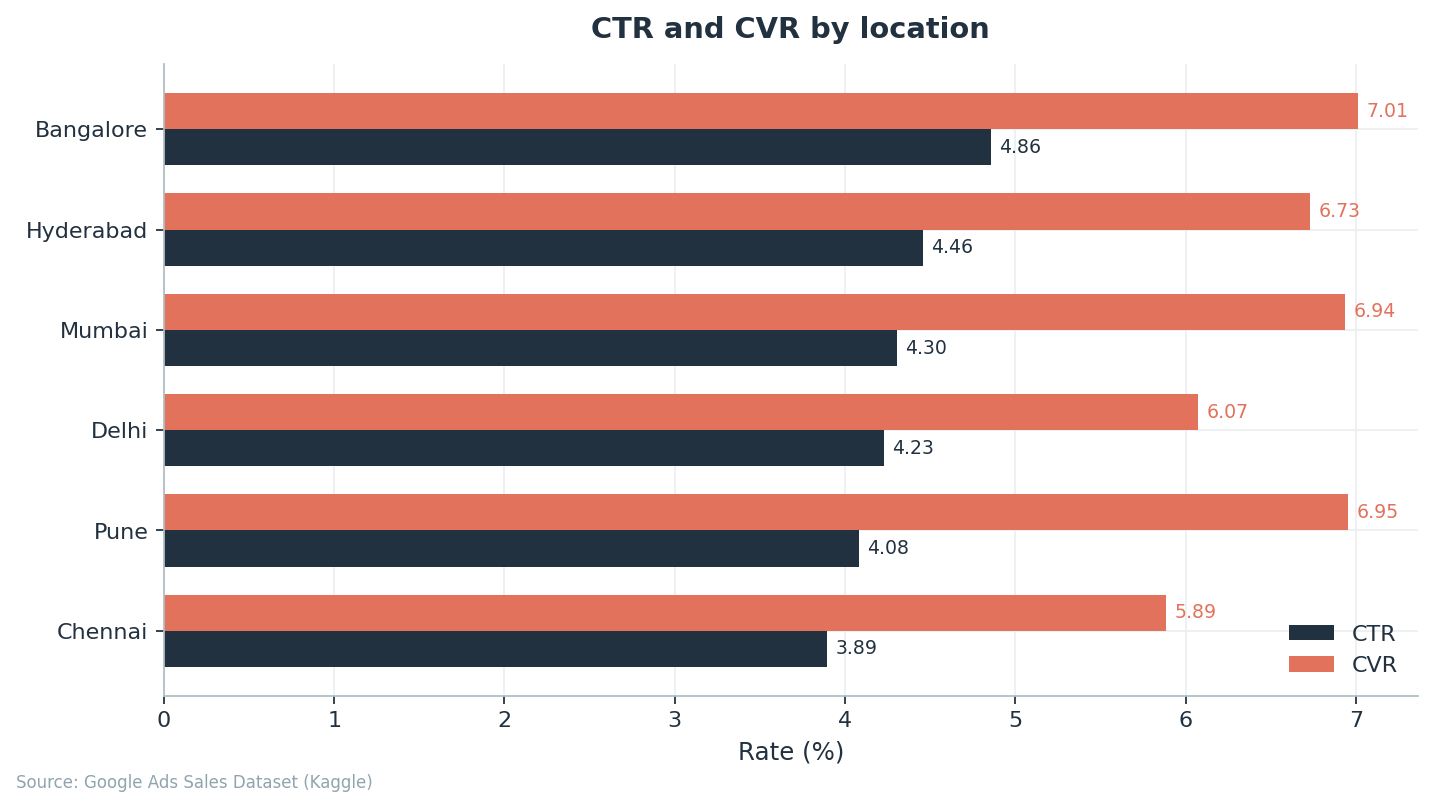

In [5]:
eda.fig_location_split(df)
display(Image("reports/figures/03_location_split.png"))

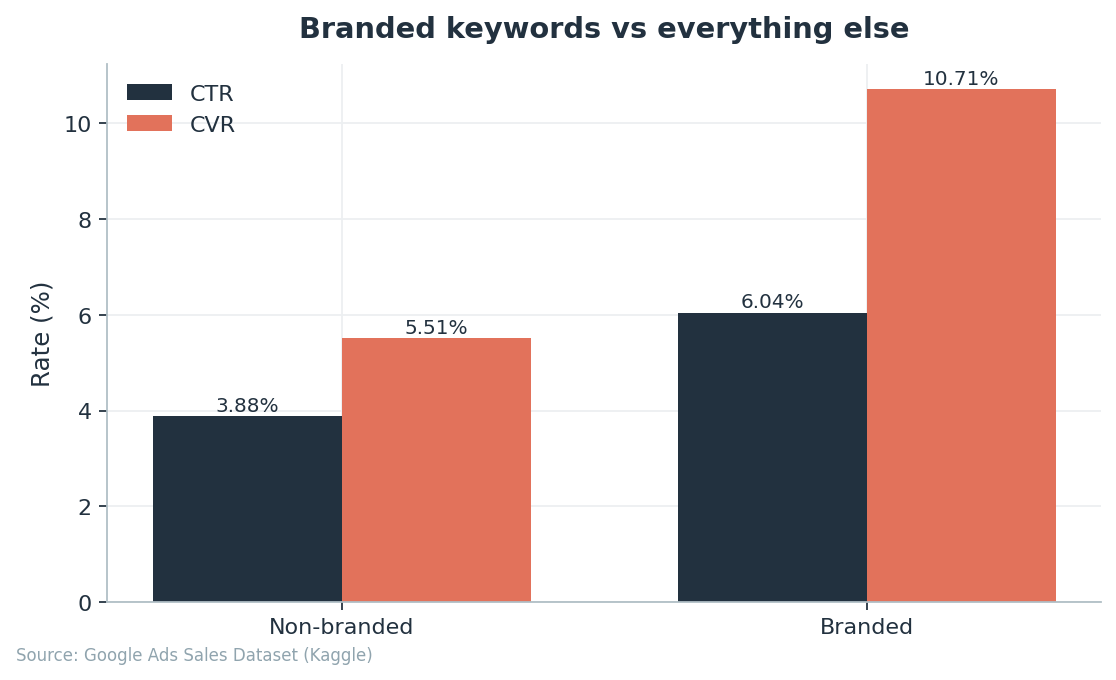

In [6]:
eda.fig_branded_split(df)
display(Image("reports/figures/04_branded_split.png"))

The branded split is the loudest signal so far. Branded queries both click
and convert at a much higher rate, which matches what practitioners see in
real accounts: someone searching for a brand is already late in the funnel.
The important consequence is that any analysis ignoring the branded flag will
attribute this lift to whatever happens to correlate with it.

## Correlations and spend

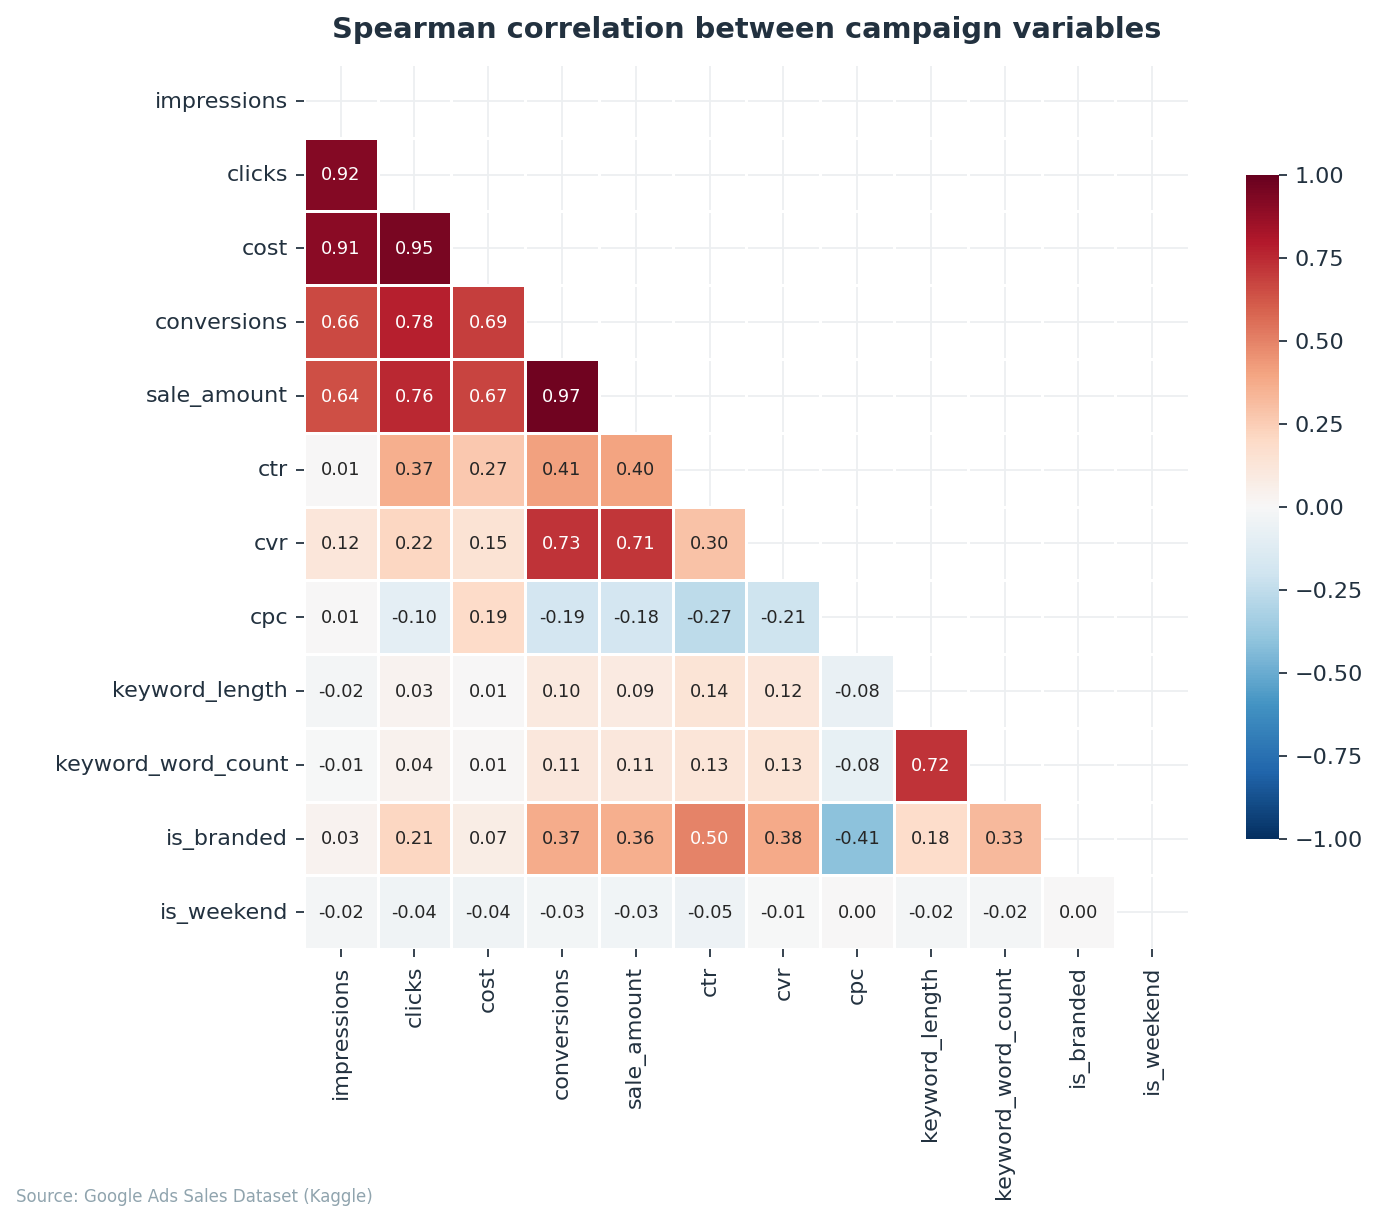

In [7]:
eda.fig_correlation(df)
display(Image("reports/figures/05_correlation_heatmap.png"))

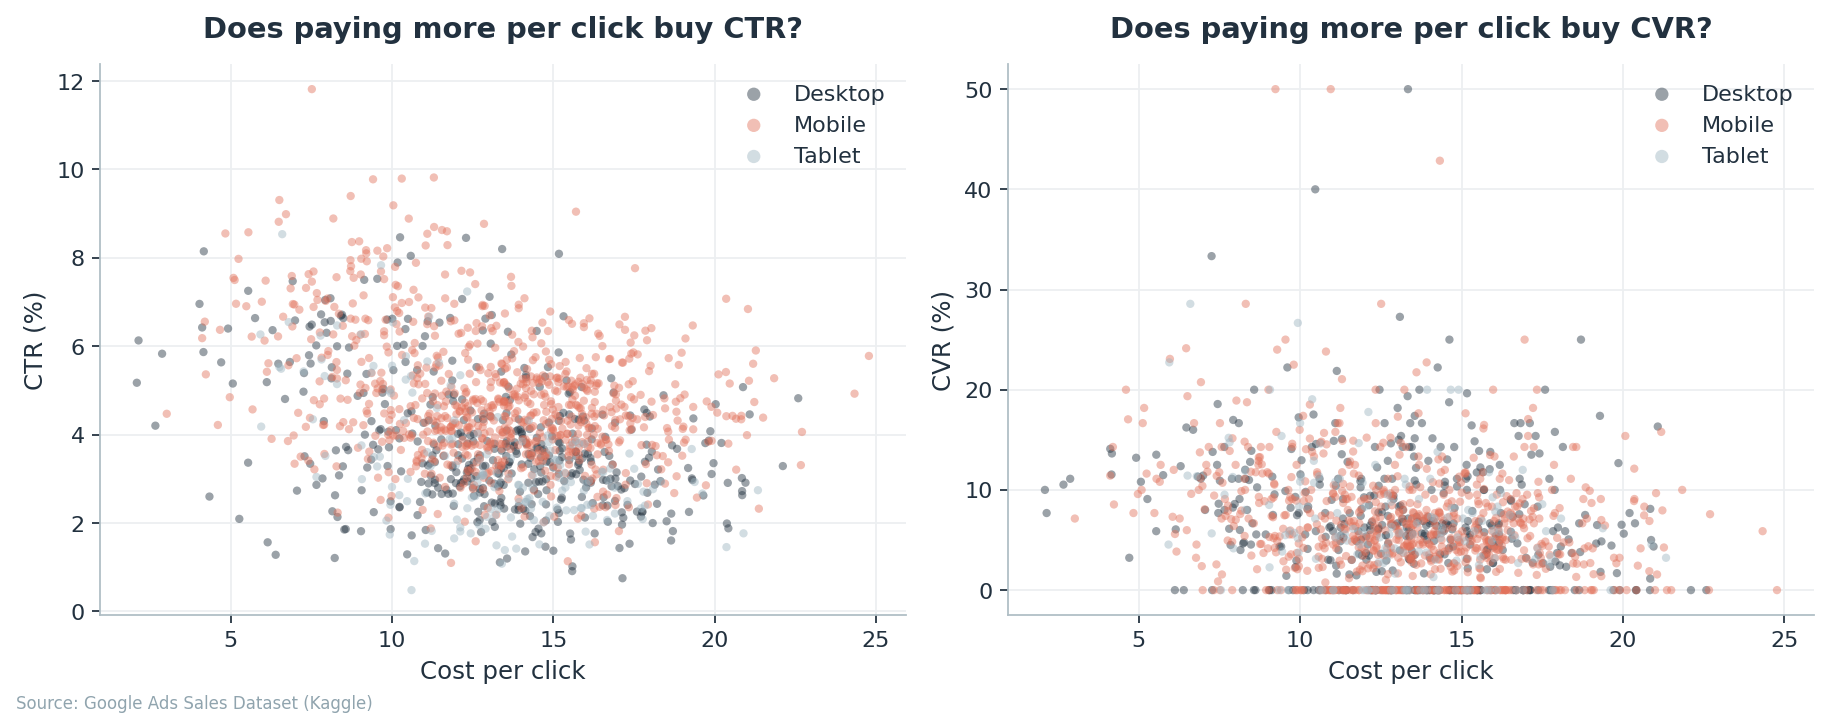

In [8]:
eda.fig_cost_vs_rates(df)
display(Image("reports/figures/06_cpc_vs_rates.png"))

## The keyword portfolio map

The chart I would put in front of a client. Each bubble is one keyword,
sized by total spend, split into four quadrants at the median CTR and median
CVR:

* **Stars** earn their budget on both metrics.
* **Hidden gems** convert well but rarely get clicked. Usually an ad copy or
  position problem, not a targeting problem.
* **Curiosity clicks** attract clicks that go nowhere, often a sign the ad
  promises something the landing page does not deliver.
* **Budget drains** underperform on both and are the first place to cut.

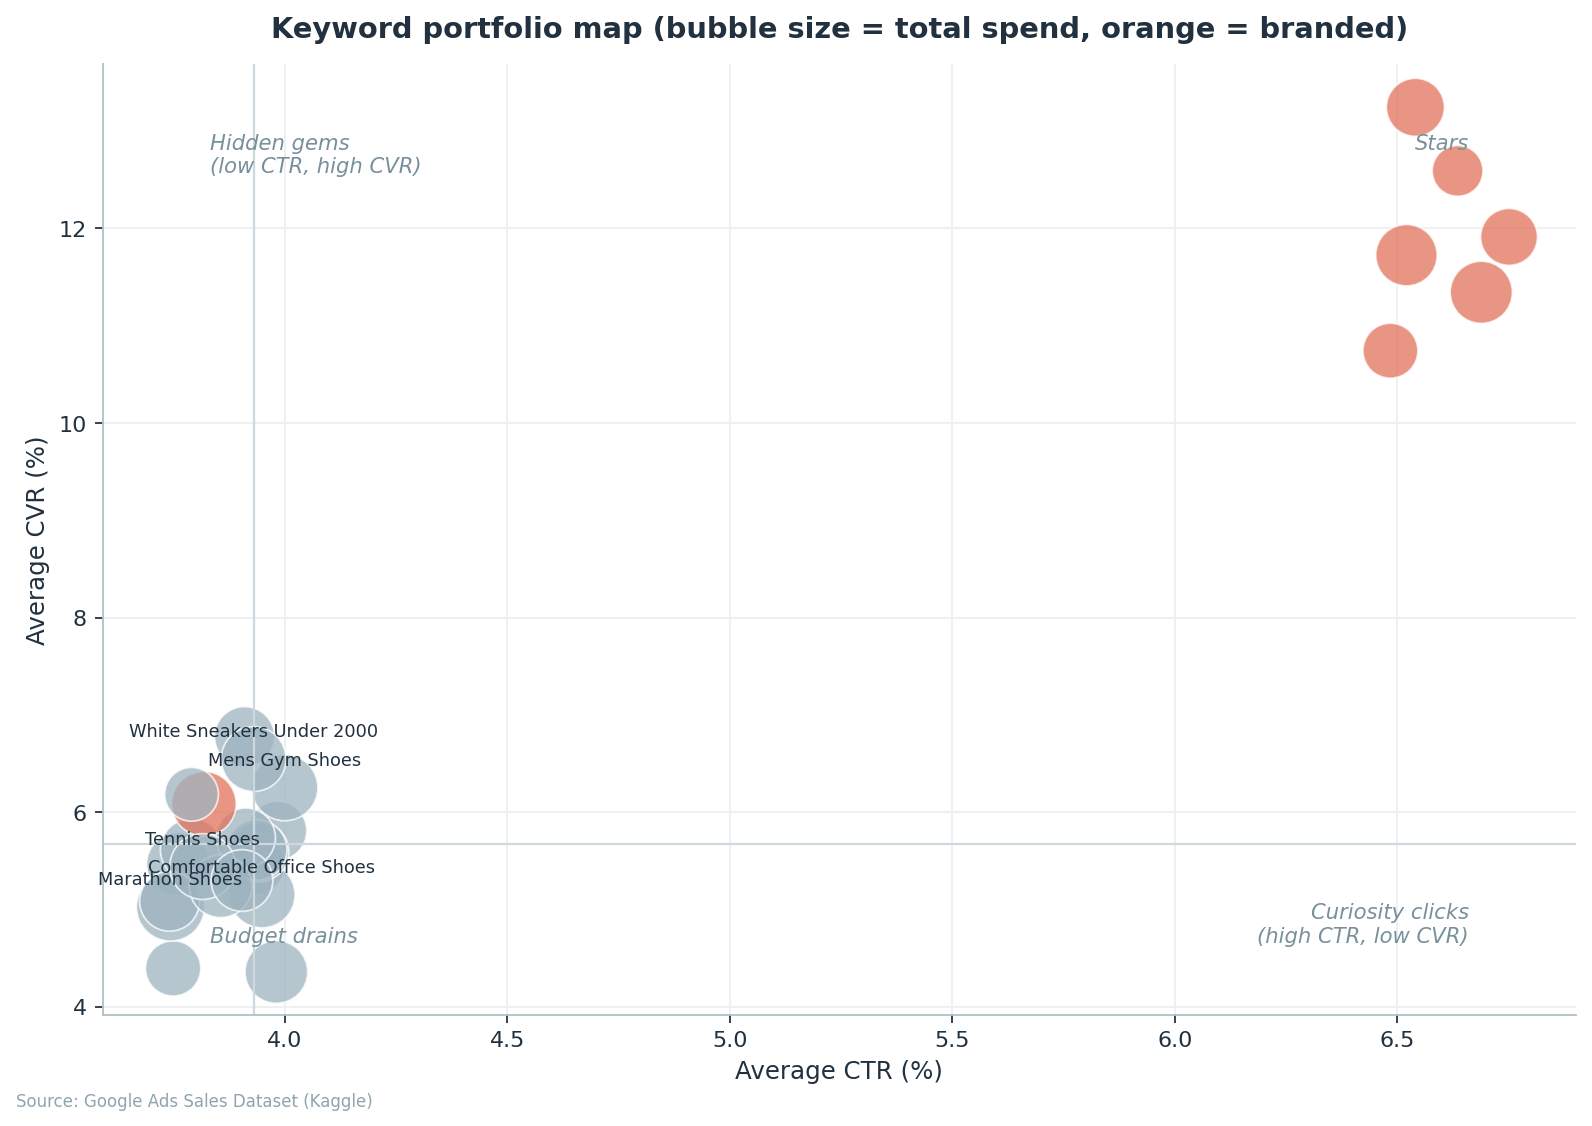

In [9]:
eda.fig_keyword_quadrants(df)
display(Image("reports/figures/07_keyword_quadrants.png"))

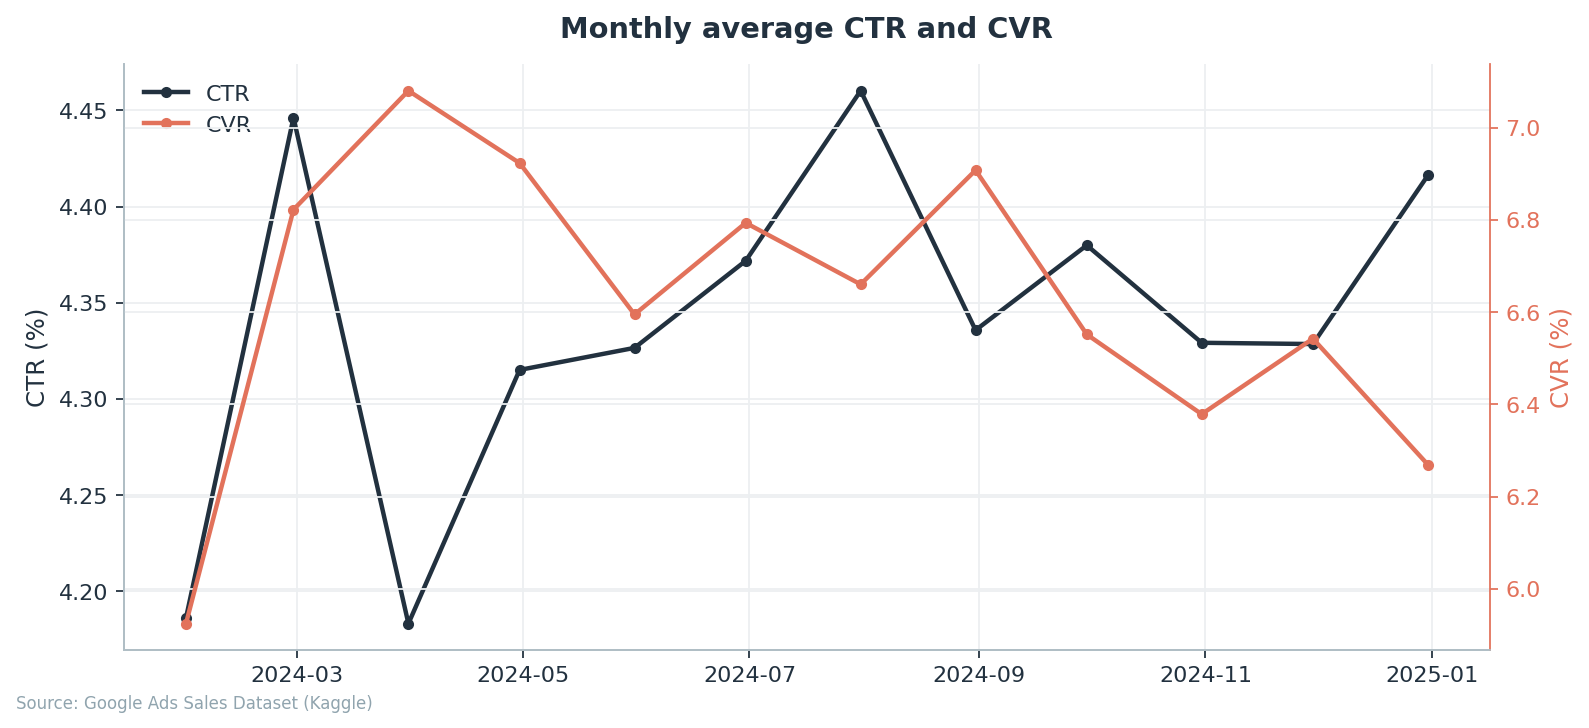

In [10]:
eda.fig_monthly_trend(df)
display(Image("reports/figures/08_monthly_trend.png"))

Continue with `03_statistical_drivers.ipynb`, where these visual impressions
get coefficients and p-values.